In [ ]:
import pandas as pd
import re

caminho = r"C:\Users\marii\OneDrive\Desktop\extracao\Extração\Extracao-Preparacao-Dados\Ex3\mises_citations_fill_page.xlsx - Sheet1.csv"

df = pd.read_csv(caminho)

def extrair_paginas(texto):
    if pd.isna(texto):
        return None
    
    # pega o último número ou intervalo (mais confiável)
    matches = re.findall(r'(?:p{1,2}\.?\s*)?(\d+(?:-\d+)?)', texto)
    
    if matches:
        return matches[-1]  # pega o último (geralmente a página certa)
    return None

df["paginas"] = df["raw"].apply(extrair_paginas)

df.to_csv("resultado.csv", index=False)

print("Pronto! Arquivo salvo como resultado.csv")

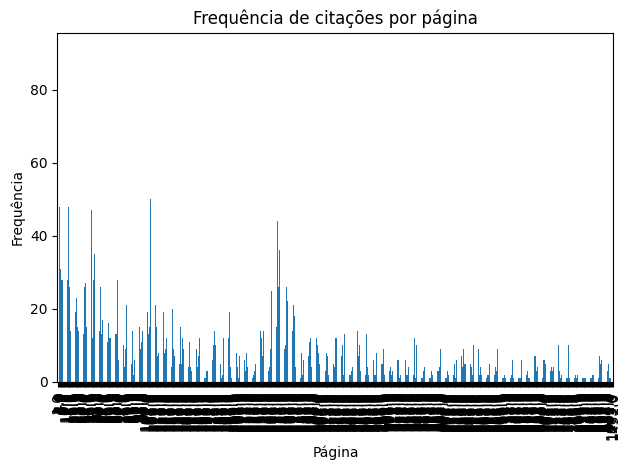

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# carregar o resultado
df = pd.read_csv("resultado.csv")

# remover vazios
paginas = df["paginas"].dropna()

# contar frequência
freq = paginas.value_counts().sort_index()

# plotar
plt.figure()
freq.plot(kind="bar")

plt.xlabel("Página")
plt.ylabel("Frequência")
plt.title("Frequência de citações por página")

plt.tight_layout()
plt.show()

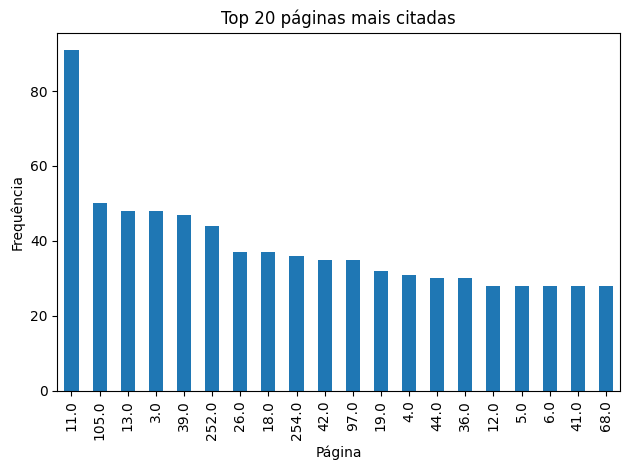

In [2]:
top = freq.sort_values(ascending=False).head(20)

plt.figure()
top.plot(kind="bar")

plt.title("Top 20 páginas mais citadas")
plt.xlabel("Página")
plt.ylabel("Frequência")

plt.tight_layout()
plt.show()

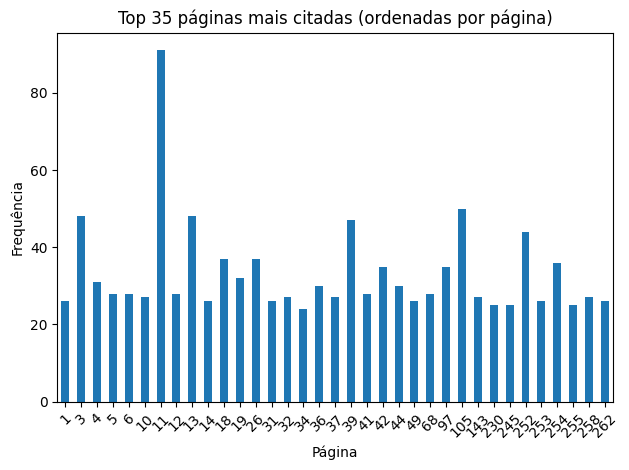

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("resultado.csv")

# limpar e garantir inteiro
paginas = df["paginas"].dropna().astype(int)

# contar frequência
freq = paginas.value_counts()

# pegar top 35 mais citadas
top35 = freq.nlargest(35)

# ordenar por número da página (crescente)
top35 = top35.sort_index()

# plotar
plt.figure()
top35.plot(kind="bar")

plt.title("Top 35 páginas mais citadas (ordenadas por página)")
plt.xlabel("Página")
plt.ylabel("Frequência")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

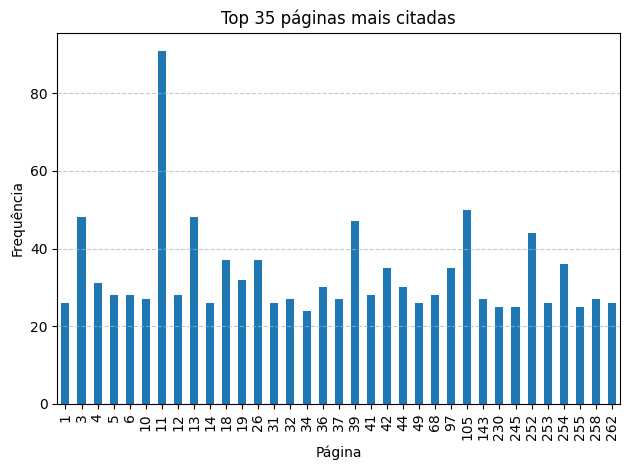

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("resultado.csv")

paginas = df["paginas"].dropna().astype(int)

freq = paginas.value_counts()

top35 = freq.nlargest(35)
top35 = top35.sort_index()

# 👇 AQUI entra o seu código de plot
plt.figure()
top35.plot(kind="bar")

plt.title("Top 35 páginas mais citadas")
plt.xlabel("Página")
plt.ylabel("Frequência")

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

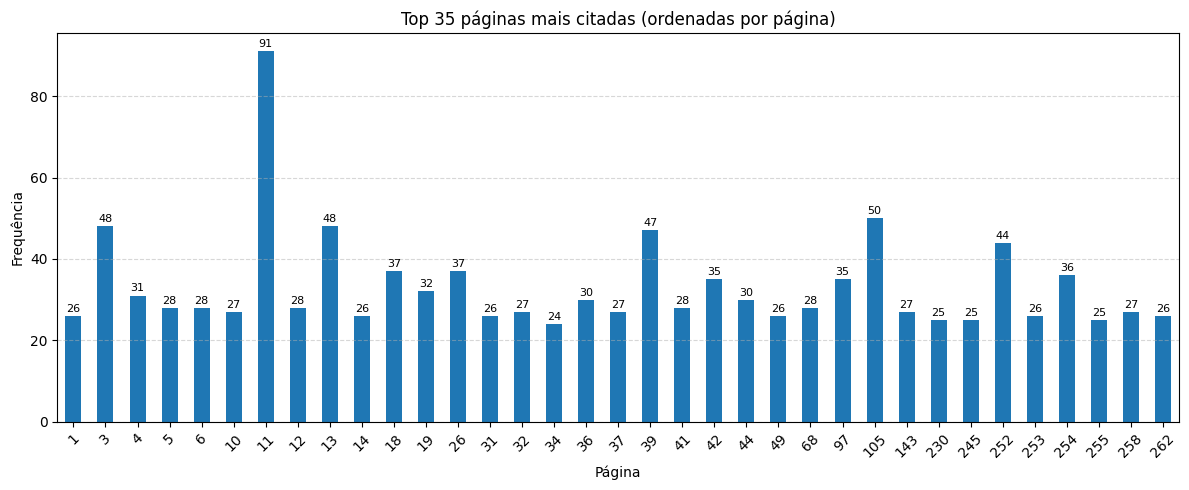

Gráfico salvo em: C:\Users\marii\OneDrive\Desktop\extracao\Extração\Extracao-Preparacao-Dados\Ex3\top35_paginas.png


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# ===== 1) Ler CSV =====
caminho = r"C:\Users\marii\OneDrive\Desktop\extracao\Extração\Extracao-Preparacao-Dados\Ex3\resultado.csv"
df = pd.read_csv(caminho)

# ===== 2) Preparar dados =====
paginas = df["paginas"].dropna().astype(int)

# Frequência por página
freq = paginas.value_counts()

# Top 35 mais citadas (por frequência)
top35 = freq.nlargest(35)

# Ordenar por número da página (crescente)
top35 = top35.sort_index()

# ===== 3) Plotar =====
plt.figure(figsize=(12, 5))
ax = top35.plot(kind="bar")

plt.title("Top 35 páginas mais citadas (ordenadas por página)")
plt.xlabel("Página")
plt.ylabel("Frequência")
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Valores em cima das barras
for i, v in enumerate(top35.values):
    ax.text(i, v + 1, str(v), ha="center", fontsize=8)

plt.xticks(rotation=45)
plt.tight_layout()

# ===== 4) Salvar e mostrar =====
saida_img = r"C:\Users\marii\OneDrive\Desktop\extracao\Extração\Extracao-Preparacao-Dados\Ex3\top35_paginas.png"
plt.savefig(saida_img, dpi=300, bbox_inches="tight")
plt.show()

print("Gráfico salvo em:", saida_img)